### DATA543 Milestone Project 
### Tao Wang 

#### We analyze the AIDev dataset containing over 933k pull requests to evaluate the performance of autonomous coding agents for this project. Our study focuses on three Research Questions (RQs):

#### - Main goals:
####   - RQ1: How do the five autonomous coding agents differ in pull-request success rate and efficiency?
####   - RQ2: Does the length of the pull-request description affect the chance of being merged, and does this effect vary across agents?
####   - RQ3: Did any of the agents improve over time (Dec 2024–Jul 2025)?

## Data Cleaning and EDA 

In [2]:
# import packages 
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# set a random seed for reproducibility
RANDOM_STATE = 123




In [9]:

# install huggingface_hub 
# %pip install "huggingface_hub[fs]" --quiet
# Login using e.g. `huggingface-cli login` to access this dataset
df = pd.read_parquet("hf://datasets/hao-li/AIDev/all_pull_request.parquet")
# take a look at the data 
print(df.shape)
print(df.head())
print(df.dtypes)



(932791, 14)
           id  number                                              title  \
0  3264016139    1688  `metta code` --> `metta clip` and additional p...   
1  3264021033      41  feat: Comprehensive ruff error resolution with...   
2  3264042289    1600  Add Evals frontend implementation plan and HTM...   
3  3264042318    1601  Add 4 new BfDs components for Evals interface ...   
4  3264067496       3  🚀 Complete Frontend-Backend API Integration wi...   

                                                body        agent    user_id  \
0  Remove unused `root_key` variable to fix ruff ...  Claude_Code      37011   
1  ## 🎯 Mission Accomplished: 100% Ruff Error Res...  Claude_Code  131842369   
2  \nCreate comprehensive implementation plan for...  Claude_Code    6766889   
3  \nPhase 1 component creation for the Evals fro...  Claude_Code    6766889   
4  ## 🎯 Summary\n\nThis PR completes the **fronte...  Claude_Code   42357482   

            user   state            created_at   

In [11]:
# we can see here: some variables are unrelated to our research questions 
# so, I decide to drop this variables, we only care about the variables are related to our research questions 
new_cols = [
    "id", "state", "created_at", "closed_at", "merged_at",
    "title", "body", "user", "user_id",
    "repo_url", "repo_id", "html_url",
    "agent"             
]
df = df[new_cols]
# double check 
df.head()

,id,state,created_at,closed_at,merged_at,title,body,user,user_id,repo_url,repo_id,html_url,agent
0,3264016139,closed,2025-07-25T18:15:36Z,2025-07-25T19:17:23Z,2025-07-25T19:17:23Z,`metta code` --> `metta clip` and additional p...,Remove unused `root_key` variable to fix ruff ...,jacklionheart,37011,https://api.github.com/repos/Metta-AI/metta,8.439884e+08,https://github.com/Metta-AI/metta/pull/1688,Claude_Code
1,3264021033,open,2025-07-25T18:17:57Z,None,None,feat: Comprehensive ruff error resolution with...,## 🎯 Mission Accomplished: 100% Ruff Error Res...,Draco3310,131842369,https://api.github.com/repos/Draco3310/Gal-Fri...,9.920635e+08,https://github.com/Draco3310/Gal-Friday2/pull/41,Claude_Code
2,3264042289,closed,2025-07-25T18:26:15Z,2025-07-25T23:19:14Z,None,Add Evals frontend implementation plan and HTM...,\nCreate comprehensive implementation plan for...,justicart,6766889,https://api.github.com/repos/bolt-foundry/bolt...,9.267118e+08,https://github.com/bolt-foundry/bolt-foundry/p...,Claude_Code
3,3264042318,closed,2025-07-25T18:26:16Z,2025-07-25T23:19:11Z,None,Add 4 new BfDs components for Evals interface ...,\nPhase 1 component creation for the Evals fro...,justicart,6766889,https://api.github.com/repos/bolt-foundry/bolt...,9.267118e+08,https://github.com/bolt-foundry/bolt-foundry/p...,Claude_Code
4,3264067496,closed,2025-07-25T18:39:14Z,2025-07-25T18:48:47Z,2025-07-25T18:48:47Z,🚀 Complete Frontend-Backend API Integration wi...,## 🎯 Summary\n\nThis PR completes the **fronte...,twitchyvr,42357482,https://api.github.com/repos/twitchyvr/Spaghetti,1.025871e+09,https://github.com/twitchyvr/Spaghetti/pull/3,Claude_Code


In [12]:
# convert timestamps to datetime
time_cols = ["created_at", "closed_at", "merged_at"]
for col in time_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# restrict to open / closed PRs, we only cares about this 
df = df[df["state"].isin(["open", "closed"])].copy()

# binary merged flag
df["merged"] = df["merged_at"].notna().astype(int)

# time_to_merge in hours (only meaningful for merged PRs)
df["time_to_merge_hours"] = (
    (df["merged_at"] - df["created_at"])
    .dt.total_seconds() / 3600
)

# PR description length
df["body"] = df["body"].fillna("")
df["body_length"] = df["body"].str.len()


# year-month and month index 
df["year_month"] = df["created_at"].dt.to_period("M").astype(str)



# sort by time and assign a sequential number to each year_month
month_order = (
    df[["year_month", "created_at"]]
    .dropna()
    .drop_duplicates("year_month")
    .sort_values("created_at")
)
month_order["month_index"] = range(1, len(month_order) + 1)

# clean data 
df = df.merge(month_order[["year_month", "month_index"]],
              on="year_month", how="left")


# take a look at the data after cleaning 
print("After we clean:", df.shape)
df.head()


/var/folders/51/n1tpfr3n4x9gtjt04l_vn1lc0000gn/T/ipykernel_98179/2831427748.py:24: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["created_at"].dt.to_period("M").astype(str)


After we clean: (932791, 18)


,id,state,created_at,closed_at,merged_at,title,body,user,user_id,repo_url,repo_id,html_url,agent,merged,time_to_merge_hours,body_length,year_month,month_index
0,3264016139,closed,2025-07-25 18:15:36+00:00,2025-07-25 19:17:23+00:00,2025-07-25 19:17:23+00:00,`metta code` --> `metta clip` and additional p...,Remove unused `root_key` variable to fix ruff ...,jacklionheart,37011,https://api.github.com/repos/Metta-AI/metta,8.439884e+08,https://github.com/Metta-AI/metta/pull/1688,Claude_Code,1,1.029722,374,2025-07,8
1,3264021033,open,2025-07-25 18:17:57+00:00,NaT,NaT,feat: Comprehensive ruff error resolution with...,## 🎯 Mission Accomplished: 100% Ruff Error Res...,Draco3310,131842369,https://api.github.com/repos/Draco3310/Gal-Fri...,9.920635e+08,https://github.com/Draco3310/Gal-Friday2/pull/41,Claude_Code,0,NaN,4045,2025-07,8
2,3264042289,closed,2025-07-25 18:26:15+00:00,2025-07-25 23:19:14+00:00,NaT,Add Evals frontend implementation plan and HTM...,\nCreate comprehensive implementation plan for...,justicart,6766889,https://api.github.com/repos/bolt-foundry/bolt...,9.267118e+08,https://github.com/bolt-foundry/bolt-foundry/p...,Claude_Code,0,NaN,1107,2025-07,8
3,3264042318,closed,2025-07-25 18:26:16+00:00,2025-07-25 23:19:11+00:00,NaT,Add 4 new BfDs components for Evals interface ...,\nPhase 1 component creation for the Evals fro...,justicart,6766889,https://api.github.com/repos/bolt-foundry/bolt...,9.267118e+08,https://github.com/bolt-foundry/bolt-foundry/p...,Claude_Code,0,NaN,884,2025-07,8
4,3264067496,closed,2025-07-25 18:39:14+00:00,2025-07-25 18:48:47+00:00,2025-07-25 18:48:47+00:00,🚀 Complete Frontend-Backend API Integration wi...,## 🎯 Summary\n\nThis PR completes the **fronte...,twitchyvr,42357482,https://api.github.com/repos/twitchyvr/Spaghetti,1.025871e+09,https://github.com/twitchyvr/Spaghetti/pull/3,Claude_Code,1,0.159167,5453,2025-07,8


## RQ1: How do the five coding agents differ in pull-request success rate and efficiency?

#### In order to answer this question, My plan is: 
#### - use only closed PRs.
#### - calculate per-agent merge rate and median time-to-merge.
#### - use a chi-square test on merge rates.
#### - use a Kruskal–Wallis test on time-to-merge.
#### - make a bar chart and boxplots.

In [13]:
# filter to closed PRs since we only care this
closed = df[df["state"] == "closed"].copy()

# calculate per-agent merge rate and median time-to-merge
agent_stats = (
    closed
    .groupby("agent", as_index=False)
    .agg(
        n_closed=("id", "size"),
        n_merged=("merged", "sum"),
        median_ttm=("time_to_merge_hours", "median")
    )
)
agent_stats["merge_rate"] = agent_stats["n_merged"] / agent_stats["n_closed"]

print(agent_stats)

          agent  n_closed  n_merged  median_ttm  merge_rate
0   Claude_Code      4734      3945    0.310278    0.833333
1       Copilot     40215     29795    0.615833    0.740893
2        Cursor     25880     23229    0.018056    0.897566
3         Devin     28066     19170    0.319167    0.683033
4  OpenAI_Codex    761032    714000    0.007778    0.938200


In [14]:
# use a chi-square test on merge rates
cont_table = pd.crosstab(closed["agent"], closed["merged"])
chi2, chi2_p_value, chi2_df, chi2_expected = stats.chi2_contingency(cont_table)

print("Chi-square test for merge rate by agent")
print("chi2 =", chi2)
print("p-value =", chi2_p_value)

Chi-square test for merge rate by agent
chi2 = 42451.509010695314
p-value = 0.0


In [15]:
#  use a Kruskal–Wallis test on time-to-merge.¶

# only for merged
merged_only = closed[closed["merged"] == 1].copy()

groups = [
    g["time_to_merge_hours"].dropna().values
    for _, g in merged_only.groupby("agent")
]

kw_stat, kw_p_value = stats.kruskal(*groups)
print("Kruskal–Wallis test for time_to_merge_hours by agent")
print("H =", kw_stat)
print("p-value =", kw_p_value)

Kruskal–Wallis test for time_to_merge_hours by agent
H = 91912.46386984251
p-value = 0.0


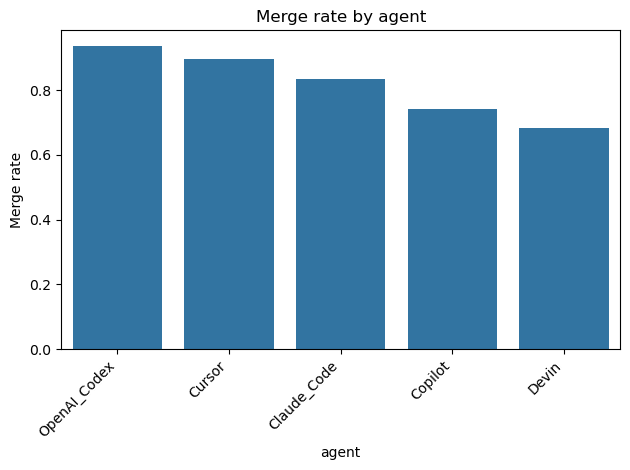

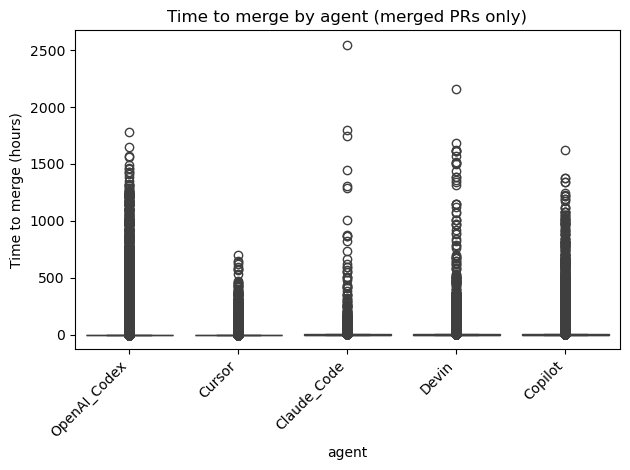

In [16]:
# make a bar chart and boxplots

#  make a plot for merge rate by agent
plt.figure()
sns.barplot(
    data=agent_stats.sort_values("merge_rate", ascending=False),
    x="agent", y="merge_rate",
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Merge rate")
plt.title("Merge rate by agent")
plt.tight_layout()
plt.show()


# make a plot for time to merge by agent (merged PRs only)
plt.figure()
order = agent_stats.sort_values("median_ttm")["agent"]
sns.boxplot(
    data=merged_only,
    x="agent", y="time_to_merge_hours",
    order=order,
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Time to merge (hours)")
plt.title("Time to merge by agent (merged PRs only)")
plt.tight_layout()
plt.show()

Based on the results we got here, we can see that 
- OpenAI_Codex has the highest merge rate (about 93.82%), while Devin is lowest (about 68.30%).
- The chi-square test shows that differences in merge rate across agents are significant since the p_value is less than 0.05. This tells us the choice of agent truly matters.
- For time-to-merge, Cursor has the shortest median time-to-merge (about 31 hours), followed closely by Claude_Code (about 31 hours as well).
- OpenAI_Codex takes longer on median (about 48 hours), and Devin is also relatively slow (about 49 hours).
- Copilot is the slowest, with a median around 66 hours.
- The Kruskal–Wallis test confirms that these timing differences are statistically significant since the p_value is less than 0.05. This tells us agents differ not only in how often they get merged but also in how quickly reviewers accept their contributions.

Overall, the results show a consistent pattern: agents with higher merge rates also tend to get merged more quickly, while Devin and Copilot lag behind in both acceptance and efficiency.



## RQ2: Does the length of the pull-request description affect the chance of being merged, and does this effect vary across agents?
#### In order to answer this question, My plan is: 
#### - calculate `body_length` and `log_body_length`.
#### - fit a logistic regression model with an interaction between length and agent.
#### - take a look at odds ratios and p-values.
#### - calculate merge rates by description-length quartile for each agent.





In [17]:

import statsmodels.formula.api as smf

# calculate body_length and log_body_length.
closed = df[df["state"] == "closed"].copy()
closed["log_body_length"] = np.log(closed["body_length"] + 1)
closed["agent"] = closed["agent"].astype("category")


#  fit a logistic regression model with an interaction between length and agent, and it can help us to see if effect differs by agent
formula = "merged ~ log_body_length * agent"
logit_model = smf.logit(formula=formula, data=closed).fit()
print(logit_model.summary())



Optimization terminated successfully.
         Current function value: 0.264657
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 merged   No. Observations:               859927
Model:                          Logit   Df Residuals:                   859917
Method:                           MLE   Df Model:                            9
Date:                Fri, 05 Dec 2025   Pseudo R-squ.:                 0.06011
Time:                        11:42:45   Log-Likelihood:            -2.2759e+05
converged:                       True   LL-Null:                   -2.4214e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                 1.2185      

In [18]:
# take a look at the odds ratios with confidence intervals, p_value
params = logit_model.params
conf = logit_model.conf_int()
odds = np.exp(params)
odds_ci = np.exp(conf)

oddratio_table = pd.DataFrame({
    "coef": params,
    "odds_ratio": odds,
    "ci_lower": odds_ci[0],
    "ci_upper": odds_ci[1],
    "p_value": logit_model.pvalues,
})
oddratio_table

,coef,odds_ratio,ci_lower,ci_upper,p_value
Intercept,1.218472,3.382018,2.154508,5.308890,1.181640e-07
agent[T.Copilot],-1.215793,0.296475,0.183343,0.479414,7.115818e-07
agent[T.Cursor],1.255628,3.510044,2.200266,5.599507,1.370100e-07
agent[T.Devin],-0.916060,0.400092,0.246532,0.649302,2.088667e-04
agent[T.OpenAI_Codex],1.329436,3.778910,2.389082,5.977258,1.326214e-08
log_body_length,0.054499,1.056012,0.992365,1.123741,8.573896e-02
log_body_length:agent[T.Copilot],0.080147,1.083447,1.014563,1.157008,1.678733e-02
log_body_length:agent[T.Cursor],-0.112537,0.893564,0.836650,0.954349,8.037313e-04
log_body_length:agent[T.Devin],0.013784,1.013879,0.947933,1.084413,6.879178e-01
log_body_length:agent[T.OpenAI_Codex],-0.023855,0.976427,0.915998,1.040843,4.642608e-01


In [19]:
# description length quartiles and merge rate by quartile x agent
closed["length_q"] = pd.qcut(
    closed["body_length"],
    q=4,
    labels=["Q1 shortest", "Q2", "Q3", "Q4 longest"],
)

q_stats = (
    closed.groupby(["agent", "length_q"], as_index=False)
          .agg(
              n=("id", "size"),
              merge_rate=("merged", "mean"),
          )
)
q_stats.head()

/var/folders/51/n1tpfr3n4x9gtjt04l_vn1lc0000gn/T/ipykernel_98179/943580377.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  closed.groupby(["agent", "length_q"], as_index=False)


,agent,length_q,n,merge_rate
0,Claude_Code,Q1 shortest,156,0.916667
1,Claude_Code,Q2,84,0.916667
2,Claude_Code,Q3,143,0.804196
3,Claude_Code,Q4 longest,4351,0.829694
4,Copilot,Q1 shortest,482,0.782158


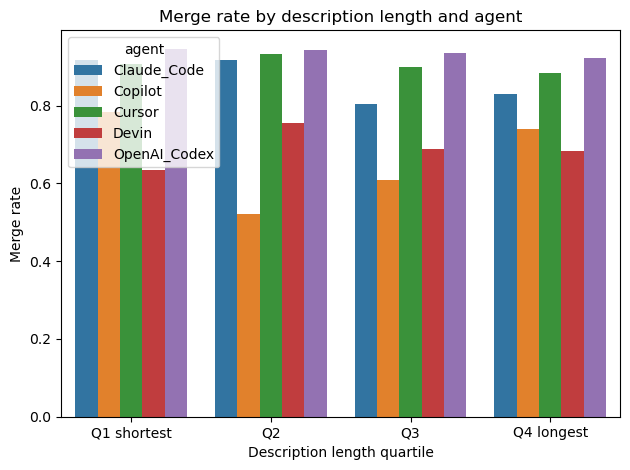

In [20]:
# make a plot for  merge rate by description-length quartile and agent
plt.figure()
sns.barplot(
    data=q_stats,
    x="length_q", y="merge_rate", hue="agent",
)
plt.ylabel("Merge rate")
plt.xlabel("Description length quartile")
plt.title("Merge rate by description length and agent")
plt.tight_layout()
plt.show()

Based on the logistic regression and the  analysis, we can see that:
- Longer descriptions do not always lead to higher merge rates. Across all agents, Q3–Q4 (longer descriptions) usually have similar or slightly higher merge rates than Q1–Q2, but the effect is not very large. In other words, length helps a bit, but it is not a major driver of merge decisions.
- Different agents react differently to description length. The interaction terms show that: Claude_Code and Devin have positive and significant interaction effects. They gain a small advantage from writing longer descriptions. Copilot and Cursor have negative and significant interaction effects. For these agents, longer descriptions are slightly less helpful. OpenAI_Codex has a non-significant interaction term.OpenAI_Codex. It means that the descriptions doesn't affect its merge rate. So, we can know that description length matters, but its impact depends on which agent you choose.
- Cursor and Codex have high merge rates regardless of description length.

## RQ3: Did any of the agents improve over time (Dec 2024–Jul 2025)?
#### In order to answer this question, My plan is:
#### - use `year_month` and `month_index`.
#### - for each agent and month, compute PR volume and merge rate.
#### - make a plot merge rate over time.
#### - calculate Spearman correlation between `month_index` and `merge_rate` per agent.


In [22]:
closed = df[df["state"] == "closed"].copy()

monthly = (
    closed.groupby(["agent", "year_month", "month_index"], as_index=False)
          .agg(
              n_pr=("id", "size"),
              merge_rate=("merged", "mean"),
          )
)
monthly.head()

,agent,year_month,month_index,n_pr,merge_rate
0,Claude_Code,2025-02,3,39,0.846154
1,Claude_Code,2025-03,4,165,0.806061
2,Claude_Code,2025-04,5,34,0.911765
3,Claude_Code,2025-05,6,385,0.732468
4,Claude_Code,2025-06,7,1435,0.845993


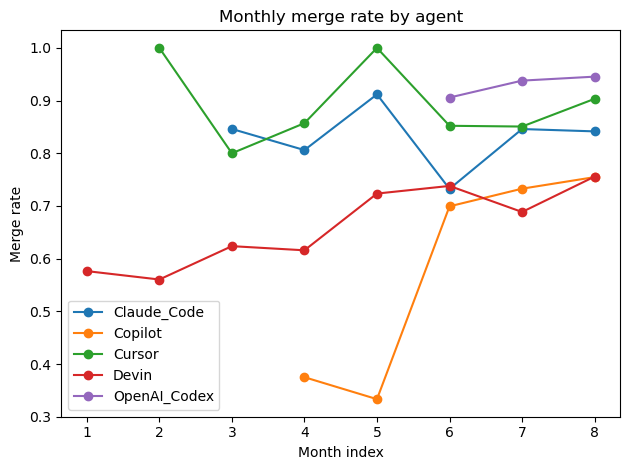

In [23]:
# make a plot for monthly merge rate over time for each agent
plt.figure()
for agent, g in monthly.groupby("agent"):
    g_sorted = g.sort_values("month_index")
    plt.plot(
        g_sorted["month_index"],
        g_sorted["merge_rate"],
        marker="o",
        label=agent,
    )

plt.xlabel("Month index")
plt.ylabel("Merge rate")
plt.title("Monthly merge rate by agent")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# calculate Spearman correlation between month_index and merge_rate per agent.
rows = []
for agent, g in monthly.groupby("agent"):
    if g["month_index"].nunique() >= 3:
        rho, p = stats.spearmanr(g["month_index"], g["merge_rate"])
        rows.append({"agent": agent, "spearman_rho": rho, "p_value": p})

trend_df = pd.DataFrame(rows)
trend_df

,agent,spearman_rho,p_value
0,Claude_Code,-0.257143,0.622787
1,Copilot,0.900000,0.037386
2,Cursor,-0.126131,0.787572
3,Devin,0.880952,0.003850
4,OpenAI_Codex,1.000000,0.000000


Based on the output we got, we can see that:
- OpenAI_Codex shows a strong positive trend over time (rho = 1.00, p < 0.001).
- Devin also has a noticeable upward trend (rho ≈ 0.88, p ≈ 0.003).
- Copilot shows a moderate positive trend (rho ≈ 0.90, p ≈ 0.037).
- Claude_Code and Cursor do not show meaningful improvement.
- Here is something very important, some fluctuations are likely due to low monthly PR counts. We can see in early months, several agents only have a small number of PRs, so a small number of merges can shift the monthly rate quite a lot.

Overall, Codex, Devin, and Copilot appear to improve over time. 